# PEMS-XGBoost NOX — optimización walk-forward R1_POC_EFFICIENT

**Propósito:** desarrollar y confirmar un regresor XGBoost exclusivamente
data-driven para NOX bajo el protocolo anual expansivo `WF_PROTOCOL_R1`.

**Alcance:** búsqueda Optuna sobre DEV 2011–2014, evaluación completa en
`WF01`, `WF02` y `WF03`, confirmación multisemilla y generación de
`BEST_CONFIG`. El año 2015 permanece cerrado durante toda la ejecución.

**Entradas:** `gt_2011.csv`–`gt_2014.csv` y artefactos FROZEN de
`00_PEMS_PINN_WF_PROTOCOL - R1.ipynb`. El OPT no construye la ruta de
`gt_2015.csv` ni consulta su existencia, cabecera, tamaño, metadatos o hash.

**Salidas:** estudio reanudable, tablas por frontera temporal, configuración
ganadora, política final de rondas, manifiesto FROZEN y handoff a
`07_XGBoost_NOX_WF_FINAL - R1F_STD.ipynb`.

**Entorno previsto:** Google Colab; CPU o CUDA se selecciona una vez mediante
preflight. **Estado inicial:** DEVELOPMENT. Solo `FULL_AUTO` puede congelar.

**Contrato científico:** nueve entradas RAW, `gbtree`, objetivo cuadrático,
sin restricciones monotónicas, física, sintéticos, selección de variables ni
escalamiento de X. Cada trial completo observa las tres fronteras DEV; TEST no
participa en búsqueda, ranking, confirmación ni política final.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, configuración y rutas |
| SEC-02 | autenticación del protocolo WF FROZEN |
| SEC-03 | materialización exclusiva de DEV y folds temporales |
| SEC-04 | núcleo XGBoost y controles unitarios |
| SEC-05 | anclas, espacio Optuna y evaluación completa |
| SEC-06 | estudio reanudable y parada adaptativa |
| SEC-07 | ranking temporal y confirmación multisemilla |
| SEC-08 | congelamiento, figuras y handoff |


## SEC-01 — Entorno, dependencias y configuración

### C-01.01 — Bootstrap de Colab

**Objetivo:** declarar la raíz única, el modo de ejecución e instalar solo
dependencias ausentes. **Control:** `RUN_MODE=SMOKE` nunca congela.


In [1]:
# [C-01.01] Bootstrap de Colab
import importlib.metadata
import importlib.util
import os
import re
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT_PATH = os.environ.get(
    "PEMS_PROJECT_ROOT",
    "/content/drive/MyDrive/Turbine_Emissions_PINN",
)
RUN_MODE = os.environ.get("PEMS_RUN_MODE", "SMOKE").upper()
DEVICE_PREFERENCE = os.environ.get("PEMS_XGB_DEVICE", "AUTO").upper()

if RUN_MODE not in {"SMOKE", "FULL_AUTO"}:
    raise ValueError("RUN_MODE debe ser SMOKE o FULL_AUTO")
if DEVICE_PREFERENCE not in {"AUTO", "CPU", "CUDA"}:
    raise ValueError("DEVICE_PREFERENCE debe ser AUTO, CPU o CUDA")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "optuna": "optuna",
    "xgboost": "xgboost>=2.0",
    "psutil": "psutil",
}
minimum_versions = {"xgboost": (2, 0)}


def major_minor(version_text: str) -> tuple[int, int]:
    numbers = [int(item) for item in re.findall(r"\d+", version_text)]
    return tuple((numbers + [0, 0])[:2])


missing_packages = []
for module, package in required_packages.items():
    if importlib.util.find_spec(module) is None:
        missing_packages.append(package)
        continue
    minimum = minimum_versions.get(module)
    if minimum is None:
        continue
    try:
        installed = importlib.metadata.version(module)
    except importlib.metadata.PackageNotFoundError:
        missing_packages.append(package)
        continue
    if major_minor(installed) < minimum:
        missing_packages.append(package)

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

print(
    {
        "entorno": "Colab" if IN_COLAB else "local",
        "run_mode": RUN_MODE,
        "dependencias_instaladas": missing_packages,
    }
)


{'entorno': 'local', 'run_mode': 'FULL_AUTO', 'dependencias_instaladas': []}


### C-01.02 / CFG-01–CFG-04 — Configuración central

**Objetivo:** fijar el contrato científico y el presupuesto antes de leer
resultados. **Salida:** una sola fuente de verdad para la campaña.


In [2]:
# [C-01.02] Imports y configuración central
from dataclasses import dataclass
from datetime import datetime, timezone
import hashlib
import importlib.metadata
import json
import math
import platform
import random
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psutil
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

VERSION = "XGBOOST_NOX_WF_OPT_R1_POC_EFFICIENT"
PROTOCOL_VERSION = "WF_PROTOCOL_R1"
CAMPAIGN_SCHEMA = "XGBOOST_NOX_WF_R1_ALL_THREE_FOLDS_FULL_EVAL"
STOP_POLICY_VERSION = "XGBOOST_POC_EFFICIENT_STOP_POLICY_V1"
FOLD_EXECUTION_POLICY = "ALL_THREE_WF_FOLDS_FULL_EVAL"
CURRENT_NOTEBOOK_NAME = "07_XGBoost_NOX_WF_OPT - R1_POC_EFFICIENT.ipynb"
UPSTREAM_NOTEBOOK_NAME = "00_PEMS_PINN_WF_PROTOCOL - R1.ipynb"
DOWNSTREAM_NOTEBOOK_NAME = "07_XGBoost_NOX_WF_FINAL - R1F_STD.ipynb"

FEATURES = [
    "AT", "AP", "AH", "AFDP", "GTEP",
    "TIT", "TAT", "TEY", "CDP",
]
TARGET = "NOX"
OTHER_TARGET = "CO"
TARGET_TRANSFORMS = ["identity"]
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
DEVELOPMENT_FOLDS = ["WF01", "WF02", "WF03"]
FINAL_FOLD = "WF04"
N_FOLDS = len(DEVELOPMENT_FOLDS)
SEARCH_SEED = 42
OPTUNA_SEED = 20260818

PURE_DATA_DRIVEN = {
    "pure_data_driven": True,
    "physics_loss": False,
    "synthetic_physics_samples": False,
    "monotone_constraints": None,
    "interaction_constraints": None,
    "other_pollutant_as_input": False,
    "feature_recipe": "RAW_9",
    "feature_scaler": None,
}

# CFG-01 — Núcleo fijo, no optimizable.
FIXED_XGB_PARAMETERS = {
    "booster": "gbtree",
    "tree_method": "hist",
    "grow_policy": "depthwise",
    "max_bin": 256,
    "objective": "reg:squarederror",
    "sampling_method": "uniform",
    "colsample_bylevel": 1.0,
    "colsample_bynode": 1.0,
    "verbosity": 0,
}

# CFG-02 — Rondas máximas altas; best_iteration es un resultado de DEV.
MAX_BOOST_ROUNDS_FULL = 4_000
EARLY_STOPPING_ROUNDS_FULL = 100
MAX_BOOST_ROUNDS_SMOKE = 200
EARLY_STOPPING_ROUNDS_SMOKE = 20

# CFG-03 — Presupuesto POC y parada práctica predefinida.
INITIAL_OPTUNA_TRIALS = 30
MAX_TOTAL_OPTUNA_TRIALS = 55
ADAPTIVE_BLOCK_SIZE = 5
ADAPTIVE_PATIENCE_BLOCKS = 2
MIN_OBJECTIVE_IMPROVEMENT = 0.002
MIN_COMPLETE_TRIALS = 12

# CFG-04 — Confirmación y política final.
TOP_N_CONFIRMATION = 3
TOP_N_FINALISTS = 2
CONFIRMATION_SCREENING_SEEDS = [21, 42, 84]
CONFIRMATION_EXTENSION_SEEDS = [126, 168]
FINAL_SEEDS = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]
ENSEMBLE_RULE = "arithmetic_mean_all_predeclared_seeds"

RAW_DATA_REL = Path("data") / "raw"
PROTOCOL_REL = Path("models") / "wf" / "work_pinn_wf_protocol"
OUTPUT_REL = Path("models/wf/work_xgboost_nox_wf_opt_r1_poc_efficient")


<USER_HOME>\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### C-01.03 / CHK-01 — Rutas, hashes y backend congelado

**Objetivo:** validar la raíz, crear salidas y seleccionar CPU/CUDA una sola
vez. El dispositivo es operativo y no participa en Optuna.


In [3]:
# [C-01.03] Utilidades, rutas y selección del backend
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def canonical_json_hash(payload: dict) -> str:
    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return sha256_bytes(encoded)


def atomic_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        dir=path.parent,
        delete=False,
    ) as handle:
        handle.write(text)
        temporary = Path(handle.name)
    temporary.replace(path)


def atomic_json(path: Path, payload: dict) -> None:
    atomic_text(path, json.dumps(payload, ensure_ascii=False, indent=2))


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        newline="",
        dir=path.parent,
        delete=False,
    ) as handle:
        frame.to_csv(handle, index=False)
        temporary = Path(handle.name)
    temporary.replace(path)


@dataclass(frozen=True)
class CampaignPaths:
    work: Path
    audit: Path
    configs: Path
    figures: Path
    optuna: Path
    reports: Path
    tables: Path


def validate_project_root(path_value: str) -> Path:
    root = Path(path_value).expanduser().resolve()
    missing = [
        root / RAW_DATA_REL / f"gt_{year}.csv"
        for year in DEVELOPMENT_YEARS
        if not (root / RAW_DATA_REL / f"gt_{year}.csv").is_file()
    ]
    if missing:
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no contiene los cuatro CSV DEV canónicos: "
            + str(missing)
        )
    return root


def create_paths(root: Path) -> CampaignPaths:
    work = root / OUTPUT_REL
    values = CampaignPaths(
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        figures=work / "figures",
        optuna=work / "optuna",
        reports=work / "reports",
        tables=work / "tables",
    )
    for path in values.__dict__.values():
        Path(path).mkdir(parents=True, exist_ok=True)
    return values


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def select_device() -> str:
    if DEVICE_PREFERENCE == "CPU":
        return "cpu"
    wants_cuda = DEVICE_PREFERENCE == "CUDA" or (
        DEVICE_PREFERENCE == "AUTO" and shutil.which("nvidia-smi") is not None
    )
    if not wants_cuda:
        return "cpu"
    try:
        trial_model = xgb.XGBRegressor(
            n_estimators=2,
            max_depth=2,
            tree_method="hist",
            device="cuda",
            objective="reg:squarederror",
            verbosity=0,
        )
        x_probe = np.arange(64, dtype=np.float32).reshape(32, 2)
        y_probe = np.arange(32, dtype=np.float32)
        trial_model.fit(x_probe, y_probe, verbose=False)
        return "cuda"
    except (xgb.core.XGBoostError, RuntimeError) as exc:
        if DEVICE_PREFERENCE == "CUDA":
            raise RuntimeError("CUDA fue exigido pero el preflight falló") from exc
        return "cpu"


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = create_paths(PROJECT_ROOT)
DEVICE = select_device()
XGB_N_JOBS = 1 if DEVICE == "cuda" else max(
    1,
    min(8, psutil.cpu_count(logical=False) or 1),
)
ACTIVE_MAX_BOOST_ROUNDS = (
    MAX_BOOST_ROUNDS_SMOKE if RUN_MODE == "SMOKE" else MAX_BOOST_ROUNDS_FULL
)
ACTIVE_EARLY_STOPPING_ROUNDS = (
    EARLY_STOPPING_ROUNDS_SMOKE
    if RUN_MODE == "SMOKE"
    else EARLY_STOPPING_ROUNDS_FULL
)
set_seed(SEARCH_SEED)

ENVIRONMENT = {
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "run_mode": RUN_MODE,
    "device": DEVICE,
    "xgb_n_jobs": XGB_N_JOBS,
    "python": sys.version,
    "platform": platform.platform(),
    "cpu_physical": psutil.cpu_count(logical=False),
    "cpu_logical": psutil.cpu_count(logical=True),
    "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
    "packages": {
        name: importlib.metadata.version(name)
        for name in [
            "numpy", "pandas", "scikit-learn", "optuna", "xgboost"
        ]
    },
}
atomic_json(PATHS.audit / "ENVIRONMENT_XGBOOST_NOX_WF_OPT_R1.json", ENVIRONMENT)
display(pd.DataFrame([ENVIRONMENT]).T.rename(columns={0: "valor"}))


,valor
version,XGBOOST_NOX_WF_OPT_R1_POC_EFFICIENT
generated_at_utc,2026-08-19T23:07:40.918288+00:00
run_mode,FULL_AUTO
device,cuda
xgb_n_jobs,1
python,"3.12.10 (tags/v3.12.10:0cc8128, Apr 8 2025, 1..."
platform,Windows-11-10.0.26200-SP0
cpu_physical,16
cpu_logical,24
ram_gib,31.746


## SEC-02 — Contrato FROZEN del protocolo R1

### C-02.01 / ALG-01 / CHK-02 — Autenticación integral

**Lógica humana:** comprobar estado y versión; autenticar los cuatro
artefactos canónicos; recalcular hashes de asignación, folds y CSV; validar
que TEST no aparece en CV. No se reconstruye ni modifica la partición.


In [4]:
# [C-02.01] Verificación del protocolo FROZEN
def verify_protocol(root: Path, paths: CampaignPaths):
    base = root / PROTOCOL_REL
    required = {
        "protocol": base / "manifests" / "WF_PROTOCOL_MANIFEST.json",
        "folds": base / "manifests" / "WF_FOLDS_MANIFEST.json",
        "consumers": base / "manifests" / "WF_CONSUMER_CONTRACT.json",
        "general": (
            base / "manifests" / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json"
        ),
        "assignment": base / "tables" / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv",
        "fold_summary": base / "tables" / "WF_FOLDS_SUMMARY.csv",
    }
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Artefactos WF FROZEN ausentes: {missing}")

    manifests = {
        name: json.loads(path.read_text(encoding="utf-8"))
        for name, path in required.items()
        if name not in {"assignment", "fold_summary"}
    }
    for name in ("protocol", "folds", "consumers", "general"):
        manifest = manifests[name]
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"{name} no está FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en {name}")

    declared = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in manifests["general"].get("artifacts", [])
    }
    canonical = {
        "manifests/WF_PROTOCOL_MANIFEST.json": required["protocol"],
        "manifests/WF_FOLDS_MANIFEST.json": required["folds"],
        "manifests/WF_CONSUMER_CONTRACT.json": required["consumers"],
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": required["assignment"],
        "tables/WF_FOLDS_SUMMARY.csv": required["fold_summary"],
    }
    for relative, path in canonical.items():
        if declared.get(relative) != sha256_file(path):
            raise RuntimeError(f"Artefacto WF no autenticado: {relative}")

    protocol = manifests["protocol"]
    folds_manifest = manifests["folds"]
    consumer = manifests["consumers"].get("common_contract", {})
    assignment = pd.read_csv(required["assignment"])
    assignment_hash = sha256_file(required["assignment"])
    fold_hash = sha256_file(required["fold_summary"])
    if assignment_hash != protocol.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación WF inconsistente")
    if assignment_hash != folds_manifest.get("row_assignment_sha256"):
        raise RuntimeError("Folds y protocolo difieren en asignación")
    if fold_hash != protocol.get("fold_summary_sha256"):
        raise RuntimeError("Hash del resumen de folds inconsistente")
    if fold_hash != folds_manifest.get("fold_summary_sha256"):
        raise RuntimeError("Resumen de folds no coincide con su manifiesto")

    required_columns = {
        "global_row_id", "year", "row_in_year", "global_position",
        *[f"{fold}_role" for fold in DEVELOPMENT_FOLDS],
    }
    if not required_columns.issubset(assignment.columns):
        raise RuntimeError("Asignación WF incompleta")
    if sorted(assignment.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("Asignación WF contiene años fuera de DEV")
    if assignment.global_row_id.duplicated().any():
        raise RuntimeError("Asignación WF contiene IDs duplicados")
    if folds_manifest.get("development_folds") != DEVELOPMENT_FOLDS:
        raise RuntimeError("Folds de desarrollo inesperados")
    if folds_manifest.get("final_fold") != FINAL_FOLD:
        raise RuntimeError("Fold final inesperado")
    expected_protocol = {
        "features": FEATURES,
        "development_years": DEVELOPMENT_YEARS,
        "final_test_year": FINAL_TEST_YEAR,
        "fixed_parameters": {
            "gap_records": 0,
            "temporal_weighting": "uniform",
        },
    }
    observed_protocol = {
        key: protocol.get(key) for key in expected_protocol
    }
    if observed_protocol != expected_protocol:
        raise RuntimeError(f"Núcleo temporal WF incompatible: {observed_protocol}")

    expected_consumer = {
        "scenario": "ANNUAL_EXPANDING_WALK_FORWARD",
        "development_years": DEVELOPMENT_YEARS,
        "development_folds": DEVELOPMENT_FOLDS,
        "final_fold": FINAL_FOLD,
        "final_test_year": FINAL_TEST_YEAR,
        "gap_records": 0,
        "temporal_weighting": "uniform",
        "opt_may_read_2015_features": False,
        "opt_may_read_2015_targets": False,
        "final_may_open_2015_after_frozen_handoff": True,
    }
    observed_consumer = {
        key: consumer.get(key) for key in expected_consumer
    }
    if observed_consumer != expected_consumer:
        raise RuntimeError(f"Contrato WF incompatible: {observed_consumer}")

    declared_dev = {
        int(item["year"]): item
        for item in protocol.get("development_data_hashes", [])
    }
    for year in DEVELOPMENT_YEARS:
        record = declared_dev.get(year)
        if record is None:
            raise RuntimeError(f"El protocolo no declara DEV {year}")
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if relative != expected or relative.is_absolute():
            raise RuntimeError(f"Ruta DEV no canónica: {relative}")
        if sha256_file(root / relative) != record.get("sha256"):
            raise RuntimeError(f"Hash inesperado para DEV {year}")

    hashes = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)).replace("\\", "/"),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(paths.audit / "PROTOCOL_INPUT_HASHES_XGBOOST_NOX_WF_R1.csv", hashes)
    return (
        assignment,
        manifests,
        assignment_hash,
        fold_hash,
        sha256_file(required["general"]),
    )


(
    ASSIGNMENT,
    PROTOCOL_MANIFESTS,
    ASSIGNMENT_HASH,
    FOLD_HASH,
    PROTOCOL_ARTIFACT_MANIFEST_HASH,
) = verify_protocol(PROJECT_ROOT, PATHS)
print(
    {
        "CHK-02": "PASS",
        "DEV_rows": len(ASSIGNMENT),
        "folds": DEVELOPMENT_FOLDS,
        "TEST_2015_materialized": False,
    }
)


{'CHK-02': 'PASS', 'DEV_rows': 29349, 'folds': ['WF01', 'WF02', 'WF03'], 'TEST_2015_materialized': False}


## SEC-03 — Materialización autorizada de DEV y folds

### C-03.01 / ALG-02 / CHK-03 — Carga assignment-first

**Lógica humana:** obtener primero los índices DEV; pedir al parser solo
esas filas; cargar RAW_9 y el objetivo seleccionado; nunca materializar el
objetivo TEST ni el otro contaminante.


In [5]:
# [C-03.01] Carga exclusiva de DEV
def load_dev_authorized(
    root: Path,
    assignment: pd.DataFrame,
    paths: CampaignPaths,
) -> tuple[pd.DataFrame, dict]:
    frames = []
    events = []
    for year in DEVELOPMENT_YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values(
            "row_in_year"
        )
        raw_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        header = pd.read_csv(raw_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, OTHER_TARGET]).issubset(header):
            raise ValueError(f"Columnas faltantes en {raw_path.name}")
        values = pd.read_csv(raw_path, usecols=FEATURES + [TARGET])[
            FEATURES + [TARGET]
        ]
        if len(values) != len(metadata):
            raise RuntimeError(f"Barrera assignment-first falló en {year}")
        identity_columns = [
            "global_row_id", "year", "row_in_year", "global_position",
            *[f"{fold}_role" for fold in DEVELOPMENT_FOLDS],
        ]
        frame = pd.concat(
            [
                metadata[identity_columns].reset_index(drop=True),
                values.reset_index(drop=True),
            ],
            axis=1,
        )
        frame["partition"] = "DEV"
        frame["block_id"] = "YEAR_" + frame.year.astype(str)
        frames.append(frame)
        events.append(
            {
                "year": year,
                "dev_rows_materialized": len(frame),
                "test_target_rows_materialized": 0,
                "test_sha256_computed": False,
                "other_pollutant_materialized": False,
            }
        )

    data = pd.concat(frames, ignore_index=True)
    if not data.partition.eq("DEV").all():
        raise RuntimeError("La tabla autorizada contiene filas no DEV")
    if data.global_row_id.duplicated().any():
        raise RuntimeError("global_row_id duplicado en DEV")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("DEV contiene NaN o infinito")

    audit = {
        "status": "PASS",
        "target": TARGET,
        "generated_at_utc": utc_now(),
        "assignment_first": True,
        "dev_rows": len(data),
        "test_target_rows_materialized": 0,
        "test_feature_rows_materialized": 0,
        "test_sha256_computed": False,
        "other_pollutant_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_XGBOOST_NOX_WF_R1.json", audit)
    return data, audit


DEV_DATA, TARGET_ACCESS_AUDIT = load_dev_authorized(
    PROJECT_ROOT,
    ASSIGNMENT,
    PATHS,
)
print(
    {
        "CHK-03": TARGET_ACCESS_AUDIT["status"],
        "DEV_rows": len(DEV_DATA),
        "TEST_y_rows": 0,
        "TEST_sha256": False,
    }
)


{'CHK-03': 'PASS', 'DEV_rows': 29349, 'TEST_y_rows': 0, 'TEST_sha256': False}


### C-03.02 / CHK-04 — Reconstrucción exacta de WF01–WF03

Cada frontera se reconstruye desde los roles FROZEN del protocolo: años
anteriores son TRAIN y el año inmediatamente posterior es VALIDATION. Se
verifican cronología, cardinalidades, ausencia de solapamiento y hashes del
assignment y del resumen anual antes de entrenar cualquier candidato.


In [6]:
# [C-03.02] Reconstrucción y auditoría de folds
def reconstruct_folds(data: pd.DataFrame):
    folds = {}
    rows = []
    manifest_rows = {
        item["fold"]: item
        for item in PROTOCOL_MANIFESTS["folds"].get("folds", [])
        if item.get("purpose") == "DEVELOPMENT"
    }
    for fold_name in DEVELOPMENT_FOLDS:
        role_column = f"{fold_name}_role"
        train_index = np.flatnonzero(data[role_column].eq("TRAIN"))
        validation_index = np.flatnonzero(data[role_column].eq("VALIDATION"))
        if not len(train_index) or not len(validation_index):
            raise RuntimeError(f"{fold_name} está vacío")
        if np.intersect1d(train_index, validation_index).size:
            raise RuntimeError(f"{fold_name} presenta solapamiento")
        train_years = sorted(data.iloc[train_index].year.unique().tolist())
        validation_years = sorted(
            data.iloc[validation_index].year.unique().tolist()
        )
        if len(validation_years) != 1 or max(train_years) >= validation_years[0]:
            raise RuntimeError(f"{fold_name} viola el orden prospectivo")
        declared = manifest_rows.get(fold_name, {})
        if train_years != declared.get("train_years"):
            raise RuntimeError(f"Train years distintos en {fold_name}")
        if validation_years[0] != declared.get("evaluation_year"):
            raise RuntimeError(f"Año de validación distinto en {fold_name}")
        if len(train_index) != int(declared.get("n_train", -1)):
            raise RuntimeError(f"N_train distinto en {fold_name}")
        if len(validation_index) != int(declared.get("n_evaluation_expected", -1)):
            raise RuntimeError(f"N_validation distinto en {fold_name}")
        folds[fold_name] = (train_index, validation_index)
        rows.append(
            {
                "fold": fold_name,
                "train_years": ",".join(map(str, train_years)),
                "validation_year": validation_years[0],
                "N_train": len(train_index),
                "N_validation": len(validation_index),
                "chronology_check": "PASS",
            }
        )
    return folds, pd.DataFrame(rows)


FOLDS, FOLD_RECONSTRUCTION = reconstruct_folds(DEV_DATA)
atomic_csv(
    PATHS.tables / "FOLD_RECONSTRUCTION_XGBOOST_NOX_WF_R1.csv",
    FOLD_RECONSTRUCTION,
)
display(FOLD_RECONSTRUCTION)


,fold,train_years,validation_year,N_train,N_validation,chronology_check
0,WF01,2011,2012,7411,7628,PASS
1,WF02,"2011,2012",2013,15039,7152,PASS
2,WF03,"2011,2012,2013",2014,22191,7158,PASS


## SEC-04 — Núcleo XGBoost puramente data-driven

### C-04.01 / ALG-03 — Transformación del objetivo y métricas físicas

**Decisión:** NOx usa solo `identity`; CO permite `identity` o `log1p`.
Early stopping y todas las comparaciones se calculan después de volver a
mg/m³. No se recortan predicciones negativas.


In [7]:
# [C-04.01] Transformaciones y métricas en escala física
def target_forward(values, transform: str) -> np.ndarray:
    if transform != "identity":
        raise ValueError("NOx R1 solo admite transformación identity")
    return np.asarray(values, dtype=float).copy()


def target_inverse(values, transform: str) -> np.ndarray:
    if transform != "identity":
        raise ValueError("NOx R1 solo admite transformación identity")
    return np.asarray(values, dtype=float).copy()


def physical_rmse_metric(transform: str):
    def physical_rmse(y_true_model, y_pred_model) -> float:
        y_true = target_inverse(y_true_model, transform)
        y_pred = target_inverse(y_pred_model, transform)
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

    physical_rmse.__name__ = "physical_rmse"
    return physical_rmse


def predictive_metrics(y_true, y_pred) -> dict:
    observed = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    residual = predicted - observed
    threshold = float(np.quantile(observed, 0.90))
    tail = observed >= threshold
    return {
        "R2": float(r2_score(observed, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(observed, predicted))),
        "MAE": float(mean_absolute_error(observed, predicted)),
        "bias": float(np.mean(residual)),
        "negative_prediction_pct": float(np.mean(predicted < 0) * 100),
        "tail_threshold": threshold,
        "tail_RMSE": float(
            np.sqrt(mean_squared_error(observed[tail], predicted[tail]))
        ),
        "tail_MAE": float(mean_absolute_error(observed[tail], predicted[tail])),
        "tail_bias": float(np.mean(residual[tail])),
    }


### C-04.02 / ALG-04 — Entrenamiento de un fold

**Entradas:** configuración, fold y semilla. **Salidas:** métricas físicas,
`best_iteration` y complejidad. El callback conserva el mejor booster.


In [8]:
# [C-04.02] Entrenamiento XGBoost por fold
def model_parameters(config: dict, seed: int, with_early_stopping: bool):
    parameters = {
        **FIXED_XGB_PARAMETERS,
        "n_estimators": ACTIVE_MAX_BOOST_ROUNDS,
        "learning_rate": float(config["learning_rate"]),
        "max_depth": int(config["max_depth"]),
        "min_child_weight": float(config["min_child_weight"]),
        "gamma": float(config["gamma"]),
        "subsample": float(config["subsample"]),
        "colsample_bytree": float(config["colsample_bytree"]),
        "reg_alpha": float(config["reg_alpha"]),
        "reg_lambda": float(config["reg_lambda"]),
        "random_state": int(seed),
        "device": DEVICE,
        "n_jobs": XGB_N_JOBS,
        "eval_metric": physical_rmse_metric(config["target_transform"]),
    }
    if with_early_stopping:
        parameters["callbacks"] = [
            xgb.callback.EarlyStopping(
                rounds=ACTIVE_EARLY_STOPPING_ROUNDS,
                metric_name="physical_rmse",
                data_name="validation_0",
                maximize=False,
                save_best=True,
            )
        ]
    return parameters


def train_fold(
    config: dict,
    fold_id: str,
    seed: int,
) -> tuple[dict, xgb.XGBRegressor]:
    train_index, validation_index = FOLDS[fold_id]
    train = DEV_DATA.iloc[train_index]
    validation = DEV_DATA.iloc[validation_index]
    x_train = train[FEATURES]
    x_validation = validation[FEATURES]
    y_train = target_forward(train[TARGET], config["target_transform"])
    y_validation = target_forward(
        validation[TARGET],
        config["target_transform"],
    )

    started = time.perf_counter()
    model = xgb.XGBRegressor(
        **model_parameters(config, seed, with_early_stopping=True)
    )
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_validation, y_validation)],
        verbose=False,
    )
    elapsed = time.perf_counter() - started
    best_iteration = int(model.best_iteration)
    prediction_model = model.predict(
        x_validation,
        iteration_range=(0, best_iteration + 1),
    )
    prediction = target_inverse(
        prediction_model,
        config["target_transform"],
    )
    metrics = predictive_metrics(validation[TARGET], prediction)
    booster = model.get_booster()
    tree_frame = booster.trees_to_dataframe()
    result = {
        "fold": str(fold_id),
        "seed": int(seed),
        "N_train": len(train),
        "N_validation": len(validation),
        "best_iteration": best_iteration,
        "effective_trees": best_iteration + 1,
        "nodes": int(len(tree_frame)),
        "leaves": int(tree_frame.Feature.eq("Leaf").sum()),
        "model_ubj_bytes": int(len(booster.save_raw(raw_format="ubj"))),
        "elapsed_seconds": float(elapsed),
        **metrics,
    }
    return result, model


def aggregate_fold_results(frame: pd.DataFrame) -> dict:
    if frame.empty:
        raise ValueError("No existen resultados de folds")
    r2_values = frame["R2"].to_numpy(float)
    return {
        "completed_folds": int(frame.fold.nunique()),
        "R2_min": float(np.min(r2_values)),
        "R2_median": float(np.median(r2_values)),
        "R2_mean": float(np.mean(r2_values)),
        "R2_std": float(np.std(r2_values, ddof=0)),
        "RMSE_median": float(frame.RMSE.median()),
        "MAE_median": float(frame.MAE.median()),
        "abs_bias_median": float(frame.bias.abs().median()),
        "tail_RMSE_median": float(frame.tail_RMSE.median()),
        "negative_prediction_pct_mean": float(
            frame.negative_prediction_pct.mean()
        ),
        "best_iteration_median": float(frame.best_iteration.median()),
        "model_ubj_bytes_median": float(frame.model_ubj_bytes.median()),
        "objective": float(
            np.min(r2_values)
            + 0.25 * np.median(r2_values)
            - 0.05 * np.std(r2_values, ddof=0)
        ),
    }


### C-04.03 / CHK-05 — Pruebas mínimas del núcleo

**Control:** transformación reversible, métricas físicas y ausencia de
parámetros físicos o monotónicos en el constructor.


In [9]:
# [C-04.03] Pruebas unitarias de alto riesgo
probe = np.array([0.0, 1.0, 10.0], dtype=float)
for transform in TARGET_TRANSFORMS:
    reconstructed = target_inverse(target_forward(probe, transform), transform)
    if not np.allclose(probe, reconstructed, rtol=1e-10, atol=1e-10):
        raise AssertionError(f"Transformación no reversible: {transform}")

base_probe_config = {
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 2.0,
    "gamma": 0.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "target_transform": TARGET_TRANSFORMS[0],
}
constructor_probe = model_parameters(
    base_probe_config,
    seed=42,
    with_early_stopping=False,
)
forbidden_parameters = {
    "monotone_constraints",
    "interaction_constraints",
    "physics_loss",
}
if forbidden_parameters & set(constructor_probe):
    raise AssertionError("El constructor contiene restricciones prohibidas")
if constructor_probe["tree_method"] != "hist":
    raise AssertionError("tree_method debe permanecer hist")
if TARGET == "NOX" and TARGET_TRANSFORMS != ["identity"]:
    raise AssertionError("NOx R1 solo admite identity")
print({"CHK-05": "PASS", "pure_data_driven": PURE_DATA_DRIVEN})


{'CHK-05': 'PASS', 'pure_data_driven': {'pure_data_driven': True, 'physics_loss': False, 'synthetic_physics_samples': False, 'monotone_constraints': None, 'interaction_constraints': None, 'other_pollutant_as_input': False, 'feature_recipe': 'RAW_9', 'feature_scaler': None}}


## SEC-05 — Anclas y espacio de búsqueda

### C-05.01 / CFG-05 — Anclas RAW_9

Incluye modelos compacto, equilibrado, regularizado y un ancla de forma
bibliográfica. Esta última no centra ni restringe el espacio Optuna.


In [10]:
# [C-05.01] Configuraciones ancla predeclaradas
def make_anchor(
    anchor_id,
    learning_rate,
    max_depth,
    min_child_weight,
    gamma,
    subsample,
    colsample_bytree,
    reg_alpha,
    reg_lambda,
    target_transform="identity",
    source="ANCHOR",
):
    return {
        "candidate_id": anchor_id,
        "source": source,
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "gamma": gamma,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "target_transform": target_transform,
    }


ANCHOR_CONFIGS = [
    make_anchor(
        "ANCHOR_COMPACT_identity",
        0.08, 4, 4.0, 0.0, 0.85, 0.85, 0.0, 2.0,
    ),
    make_anchor(
        "ANCHOR_BALANCED_identity",
        0.04, 8, 8.0, 0.05, 0.80, 0.90, 1e-4, 10.0,
    ),
    make_anchor(
        "ANCHOR_REGULARIZED_identity",
        0.02, 12, 32.0, 0.20, 0.70, 0.75, 0.01, 50.0,
    ),
    make_anchor(
        "ANCHOR_INTERP_CHAMPION_identity",
        0.0060316441,
        13,
        1.54679,
        0.0,
        0.610832,
        0.944449,
        0.0,
        0.108472,
        source="TRANSFER_ANCHOR_NOX_INTERP_R1_OPTUNA_0047",
    ),
]
display(pd.DataFrame(ANCHOR_CONFIGS))


,candidate_id,source,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,reg_lambda,target_transform
0,ANCHOR_COMPACT_identity,ANCHOR,0.080000,4,4.00000,0.00,0.850000,0.850000,0.0000,2.000000,identity
1,ANCHOR_BALANCED_identity,ANCHOR,0.040000,8,8.00000,0.05,0.800000,0.900000,0.0001,10.000000,identity
2,ANCHOR_REGULARIZED_identity,ANCHOR,0.020000,12,32.00000,0.20,0.700000,0.750000,0.0100,50.000000,identity
3,ANCHOR_INTERP_CHAMPION_identity,TRANSFER_ANCHOR_NOX_INTERP_R1_OPTUNA_0047,0.006032,13,1.54679,0.00,0.610832,0.944449,0.0000,0.108472,identity


### C-05.02 / CFG-06 — Espacio Optuna focalizado

Se optimizan ocho hiperparámetros nativos y, solo para CO, la transformación
del objetivo. `n_estimators`, `max_bin`, backend y receta de variables no
forman parte de la búsqueda.


In [11]:
# [C-05.02] Muestreo del espacio científico R1
def suggest_zero_or_log(trial, name: str, upper: float) -> float:
    is_active = trial.suggest_categorical(f"{name}_active", [False, True])
    if not is_active:
        return 0.0
    return float(trial.suggest_float(f"{name}_nonzero", 1e-8, upper, log=True))


def sample_config(trial: optuna.Trial) -> dict:
    return {
        "candidate_id": f"OPTUNA_{trial.number:04d}",
        "source": "OPTUNA",
        "learning_rate": float(
            trial.suggest_float("learning_rate", 0.005, 0.30, log=True)
        ),
        "max_depth": int(trial.suggest_int("max_depth", 2, 16)),
        "min_child_weight": float(
            trial.suggest_float("min_child_weight", 0.5, 256.0, log=True)
        ),
        "gamma": suggest_zero_or_log(trial, "gamma", 20.0),
        "subsample": float(trial.suggest_float("subsample", 0.55, 1.0)),
        "colsample_bytree": float(
            trial.suggest_float("colsample_bytree", 0.55, 1.0)
        ),
        "reg_alpha": suggest_zero_or_log(trial, "reg_alpha", 10.0),
        "reg_lambda": float(
            trial.suggest_float("reg_lambda", 1e-3, 1e3, log=True)
        ),
        "target_transform": trial.suggest_categorical(
            "target_transform", TARGET_TRANSFORMS
        ),
    }


def evaluate_candidate(
    config: dict,
    seed: int,
    fold_order: list[str],
    trial: optuna.Trial | None = None,
) -> tuple[pd.DataFrame, dict]:
    rows = []
    for step, fold_name in enumerate(fold_order):
        fold_result, _ = train_fold(config, fold_name, seed)
        rows.append({"candidate_id": config["candidate_id"], **fold_result})
        if trial is not None:
            partial_summary = aggregate_fold_results(pd.DataFrame(rows))
            trial.report(partial_summary["objective"], step=step)
    result_frame = pd.DataFrame(rows)
    if result_frame.fold.nunique() != N_FOLDS:
        raise RuntimeError("Un candidato no completó las tres fronteras WF")
    return result_frame, aggregate_fold_results(result_frame)


## SEC-06 — Optuna reanudable y parada adaptativa

### C-06.01 / ALG-05 — Anclas y objetivo 2+3 folds

**Lógica:** evaluar anclas; usar folds 0 y 3 como screening; promover solo
candidatos competitivos a los otros tres; optimizar un objetivo robusto
dominado por el peor fold. TEST no participa.


In [12]:
# [C-06.01] Evaluación de anclas y función objetivo
ACTIVE_FOLD_ORDER = list(DEVELOPMENT_FOLDS)
if RUN_MODE == "FULL_AUTO":
    ACTIVE_ANCHOR_CONFIGS = list(ANCHOR_CONFIGS)
    ANCHOR_EXECUTION_POLICY = "FULL_AUTO_ALL_FOUR_PREDECLARED_ANCHORS"
else:
    ACTIVE_ANCHOR_CONFIGS = [
        config
        for config in ANCHOR_CONFIGS
        if config["candidate_id"] == "ANCHOR_INTERP_CHAMPION_identity"
    ]
    ANCHOR_EXECUTION_POLICY = "SMOKE_ONE_TRANSFER_ANCHOR_PLUS_TWO_TRIALS"
if len(ACTIVE_ANCHOR_CONFIGS) != (4 if RUN_MODE == "FULL_AUTO" else 1):
    raise RuntimeError("Política de anclas no pudo materializarse")

CAMPAIGN_FINGERPRINT_PAYLOAD = {
    "schema": "XGBOOST_NOX_WF_CAMPAIGN_FINGERPRINT_V1",
    "version": VERSION,
    "run_mode": RUN_MODE,
    "protocol_version": PROTOCOL_VERSION,
    "target": TARGET,
    "features": FEATURES,
    "target_transforms": TARGET_TRANSFORMS,
    "development_years": DEVELOPMENT_YEARS,
    "development_folds": DEVELOPMENT_FOLDS,
    "fold_execution_policy": FOLD_EXECUTION_POLICY,
    "assignment_sha256": ASSIGNMENT_HASH,
    "fold_summary_sha256": FOLD_HASH,
    "protocol_artifact_manifest_sha256": PROTOCOL_ARTIFACT_MANIFEST_HASH,
    "backend": DEVICE,
    "xgb_n_jobs": XGB_N_JOBS,
    "optuna_n_jobs": 1,
    "xgboost_version": xgb.__version__,
    "fixed_xgb_parameters": FIXED_XGB_PARAMETERS,
    "objective_contract": {
        "formula": "R2_min+0.25*R2_median-0.05*R2_std",
        "direction": "maximize",
        "pruner": "NopPruner",
        "all_three_folds_required": True,
    },
    "confirmation_screening_seeds": CONFIRMATION_SCREENING_SEEDS,
    "confirmation_extension_seeds": CONFIRMATION_EXTENSION_SEEDS,
    "final_seeds": FINAL_SEEDS,
    "ensemble_rule": ENSEMBLE_RULE,
    "anchor_execution_policy": ANCHOR_EXECUTION_POLICY,
    "anchors": ACTIVE_ANCHOR_CONFIGS,
    "search_space": {
        "learning_rate": [0.005, 0.30, "log"],
        "max_depth": [2, 16],
        "min_child_weight": [0.5, 256.0, "log"],
        "gamma": [0.0, 1e-8, 20.0, "zero_or_log"],
        "subsample": [0.55, 1.0],
        "colsample_bytree": [0.55, 1.0],
        "reg_alpha": [0.0, 1e-8, 10.0, "zero_or_log"],
        "reg_lambda": [1e-3, 1e3, "log"],
    },
    "search_seed": SEARCH_SEED,
    "optuna_seed": OPTUNA_SEED,
    "max_boost_rounds": ACTIVE_MAX_BOOST_ROUNDS,
    "early_stopping_rounds": ACTIVE_EARLY_STOPPING_ROUNDS,
    "stop_policy": {
        "version": STOP_POLICY_VERSION,
        "initial_trials": INITIAL_OPTUNA_TRIALS,
        "hard_cap": MAX_TOTAL_OPTUNA_TRIALS,
        "block_size": ADAPTIVE_BLOCK_SIZE,
        "patience_blocks": ADAPTIVE_PATIENCE_BLOCKS,
        "minimum_gain": MIN_OBJECTIVE_IMPROVEMENT,
        "minimum_complete_trials": MIN_COMPLETE_TRIALS,
    },
}
CAMPAIGN_FINGERPRINT = canonical_json_hash(CAMPAIGN_FINGERPRINT_PAYLOAD)
CAMPAIGN_FINGERPRINT_PATH = (
    PATHS.optuna
    / f"CAMPAIGN_FINGERPRINT_{RUN_MODE}_XGBOOST_NOX_WF_R1.json"
)
CAMPAIGN_FINGERPRINT_RECORD = {
    "status": "DECLARED",
    "generated_at_utc": utc_now(),
    "campaign_fingerprint": CAMPAIGN_FINGERPRINT,
    "payload": CAMPAIGN_FINGERPRINT_PAYLOAD,
}

anchor_fold_frames = []
anchor_summaries = []
for anchor in ACTIVE_ANCHOR_CONFIGS:
    fold_frame, summary = evaluate_candidate(
        anchor,
        seed=SEARCH_SEED,
        fold_order=ACTIVE_FOLD_ORDER,
    )
    anchor_fold_frames.append(fold_frame)
    anchor_summaries.append({**anchor, **summary})

ANCHOR_FOLDS = pd.concat(anchor_fold_frames, ignore_index=True)
ANCHOR_SUMMARY = pd.DataFrame(anchor_summaries)
atomic_csv(PATHS.tables / "ANCHOR_FOLDS_XGBOOST_NOX_WF_R1.csv", ANCHOR_FOLDS)
atomic_csv(PATHS.tables / "ANCHOR_SUMMARY_XGBOOST_NOX_WF_R1.csv", ANCHOR_SUMMARY)


def objective(trial: optuna.Trial) -> float:
    config = sample_config(trial)
    fold_frame, summary = evaluate_candidate(
        config,
        seed=SEARCH_SEED,
        fold_order=ACTIVE_FOLD_ORDER,
        trial=trial,
    )
    trial.set_user_attr("config", config)
    trial.set_user_attr("summary", summary)
    trial.set_user_attr(
        "fold_results",
        json.loads(fold_frame.to_json(orient="records")),
    )
    return float(summary["objective"])


display(
    ANCHOR_SUMMARY[
        [
            "candidate_id",
            "target_transform",
            "completed_folds",
            "R2_min",
            "R2_median",
            "RMSE_median",
            "objective",
        ]
    ].sort_values("objective", ascending=False)
)


,candidate_id,target_transform,completed_folds,R2_min,R2_median,RMSE_median,objective
0,ANCHOR_COMPACT_identity,identity,3,-0.035950,0.601328,7.606790,0.097423
1,ANCHOR_BALANCED_identity,identity,3,-0.051609,0.619549,7.430928,0.085755
3,ANCHOR_INTERP_CHAMPION_identity,identity,3,-0.071990,0.613155,7.493106,0.063693
2,ANCHOR_REGULARIZED_identity,identity,3,-0.102692,0.615291,7.472390,0.032689


### C-06.02 / ALG-06 / ART-01 — Estudio SQLite y campaña

En FULL se ejecutan al menos 30 intentos y se continúa en bloques de cinco
hasta convergencia práctica o 55 intentos. SMOKE usa dos ensayos y no congela.


In [13]:
# [C-06.02] Estudio persistente y parada adaptativa
storage_path = PATHS.optuna / f"{TARGET}_XGBOOST_WF_{RUN_MODE}_R1.sqlite"
storage_url = "sqlite:///" + str(storage_path).replace("\\", "/")
study = optuna.create_study(
    study_name=f"{TARGET}_XGBOOST_WF_{RUN_MODE}_R1",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=OPTUNA_SEED, multivariate=True),
    pruner=optuna.pruners.NopPruner(),
    storage=storage_url,
    load_if_exists=True,
)
stored_fingerprint = study.user_attrs.get("campaign_fingerprint")
if stored_fingerprint is None:
    if study.trials:
        raise RuntimeError(
            "SQLite existente contiene trials sin fingerprint autenticado"
        )
    study.set_user_attr("campaign_fingerprint", CAMPAIGN_FINGERPRINT)
    study.set_user_attr("campaign_schema", CAMPAIGN_SCHEMA)
elif stored_fingerprint != CAMPAIGN_FINGERPRINT:
    raise RuntimeError("SQLite pertenece a otra campaña metodológica")
if study.user_attrs.get("campaign_schema") != CAMPAIGN_SCHEMA:
    raise RuntimeError("Schema persistido de la campaña no coincide")
# El sidecar se consulta solo después de autenticar la SQLite. Un mismatch o
# rerun fallido no puede sobrescribir evidencia FROZEN de una campaña previa.
if CAMPAIGN_FINGERPRINT_PATH.is_file():
    existing_fingerprint_record = json.loads(
        CAMPAIGN_FINGERPRINT_PATH.read_text(encoding="utf-8")
    )
    if existing_fingerprint_record.get(
        "campaign_fingerprint"
    ) != CAMPAIGN_FINGERPRINT:
        raise RuntimeError("Sidecar existente pertenece a otra campaña")
    CAMPAIGN_FINGERPRINT_RECORD = existing_fingerprint_record
else:
    atomic_json(CAMPAIGN_FINGERPRINT_PATH, CAMPAIGN_FINGERPRINT_RECORD)


def attempted_trials(current_study) -> int:
    terminal = {
        optuna.trial.TrialState.COMPLETE,
        optuna.trial.TrialState.PRUNED,
        optuna.trial.TrialState.FAIL,
    }
    return sum(trial.state in terminal for trial in current_study.trials)


def complete_trials(current_study) -> int:
    return sum(
        trial.state == optuna.trial.TrialState.COMPLETE
        for trial in current_study.trials
    )


STOP_HISTORY = []
if RUN_MODE == "SMOKE":
    remaining = max(0, 2 - attempted_trials(study))
    if remaining:
        study.optimize(objective, n_trials=remaining, n_jobs=1, gc_after_trial=True)
    CAMPAIGN_COMPLETE = False
    STOP_REASON = "SMOKE_ONLY_NO_FREEZE"
else:
    stale_blocks = 0
    previous_best = study.best_value if complete_trials(study) else -np.inf
    while attempted_trials(study) < MAX_TOTAL_OPTUNA_TRIALS:
        attempted_before = attempted_trials(study)
        if attempted_before < INITIAL_OPTUNA_TRIALS:
            block = min(
                INITIAL_OPTUNA_TRIALS - attempted_before,
                MAX_TOTAL_OPTUNA_TRIALS - attempted_before,
            )
        else:
            block = min(
                ADAPTIVE_BLOCK_SIZE,
                MAX_TOTAL_OPTUNA_TRIALS - attempted_before,
            )
        study.optimize(objective, n_trials=block, n_jobs=1, gc_after_trial=True)
        current_best = study.best_value if complete_trials(study) else -np.inf
        improvement = current_best - previous_best
        if attempted_trials(study) >= INITIAL_OPTUNA_TRIALS:
            stale_blocks = (
                stale_blocks + 1
                if improvement < MIN_OBJECTIVE_IMPROVEMENT
                else 0
            )
        STOP_HISTORY.append(
            {
                "attempted": attempted_trials(study),
                "complete": complete_trials(study),
                "best_objective": current_best,
                "block_improvement": improvement,
                "stale_blocks": stale_blocks,
            }
        )
        previous_best = max(previous_best, current_best)
        if (
            attempted_trials(study) >= INITIAL_OPTUNA_TRIALS
            and complete_trials(study) >= MIN_COMPLETE_TRIALS
            and stale_blocks >= ADAPTIVE_PATIENCE_BLOCKS
        ):
            break
    CAMPAIGN_COMPLETE = (
        attempted_trials(study) >= INITIAL_OPTUNA_TRIALS
        and complete_trials(study) >= MIN_COMPLETE_TRIALS
    )
    STOP_REASON = (
        "PRACTICAL_PLATEAU"
        if stale_blocks >= ADAPTIVE_PATIENCE_BLOCKS
        else "HARD_CAP"
    )

STOP_HISTORY_FRAME = pd.DataFrame(STOP_HISTORY)
atomic_csv(PATHS.tables / "STOP_HISTORY_XGBOOST_NOX_WF_R1.csv", STOP_HISTORY_FRAME)
print(
    {
        "attempted": attempted_trials(study),
        "complete": complete_trials(study),
        "campaign_complete": CAMPAIGN_COMPLETE,
        "stop_reason": STOP_REASON,
        "fold_policy": FOLD_EXECUTION_POLICY,
    }
)


<USER_HOME>\AppData\Local\Temp\ipykernel_53460\3481382956.py:7: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=OPTUNA_SEED, multivariate=True),


[I 2026-08-19 18:09:34,431] A new study created in RDB with name: NOX_XGBOOST_WF_FULL_AUTO_R1


[I 2026-08-19 18:09:46,685] Trial 0 finished with value: 0.05390131097649507 and parameters: {'learning_rate': 0.218504539704629, 'max_depth': 15, 'min_child_weight': 1.298166890972207, 'gamma_active': False, 'subsample': 0.6145484157041747, 'colsample_bytree': 0.676885700915847, 'reg_alpha_active': False, 'reg_lambda': 0.0018207839875640825, 'target_transform': 'identity'}. Best is trial 0 with value: 0.05390131097649507.


[I 2026-08-19 18:10:09,136] Trial 1 finished with value: 0.03841250086079881 and parameters: {'learning_rate': 0.019744680432180257, 'max_depth': 13, 'min_child_weight': 1.84565809412724, 'gamma_active': True, 'gamma_nonzero': 1.9626853455515822, 'subsample': 0.9918968305619796, 'colsample_bytree': 0.934759816891166, 'reg_alpha_active': True, 'reg_alpha_nonzero': 0.15076439526739072, 'reg_lambda': 0.7004806522483423, 'target_transform': 'identity'}. Best is trial 0 with value: 0.05390131097649507.


[I 2026-08-19 18:10:28,822] Trial 2 finished with value: 0.0910324736280491 and parameters: {'learning_rate': 0.0285001583577394, 'max_depth': 16, 'min_child_weight': 7.834380338781937, 'gamma_active': False, 'subsample': 0.5918011915466642, 'colsample_bytree': 0.9028649339306913, 'reg_alpha_active': True, 'reg_alpha_nonzero': 0.08675147806205649, 'reg_lambda': 15.567546971387802, 'target_transform': 'identity'}. Best is trial 2 with value: 0.0910324736280491.


...

[I 2026-08-19 18:27:27,446] Trial 36 finished with value: 0.08521645264817793 and parameters: {'learning_rate': 0.029278362817840672, 'max_depth': 15, 'min_child_weight': 1.8138899048984942, 'gamma_active': False, 'subsample': 0.5503302639112433, 'colsample_bytree': 0.8566029745849502, 'reg_alpha_active': False, 'reg_lambda': 171.76341318035222, 'target_transform': 'identity'}. Best is trial 27 with value: 0.13634913343417887.


[I 2026-08-19 18:27:59,316] Trial 37 finished with value: 0.12310309212453126 and parameters: {'learning_rate': 0.026059061436984554, 'max_depth': 11, 'min_child_weight': 16.24842909503088, 'gamma_active': True, 'gamma_nonzero': 1.5260887773187247e-06, 'subsample': 0.5691349410594325, 'colsample_bytree': 0.9497647989760583, 'reg_alpha_active': False, 'reg_lambda': 973.1796258321739, 'target_transform': 'identity'}. Best is trial 27 with value: 0.13634913343417887.


[I 2026-08-19 18:28:29,487] Trial 38 finished with value: 0.07324111653077532 and parameters: {'learning_rate': 0.040688821772459575, 'max_depth': 15, 'min_child_weight': 7.405959450550278, 'gamma_active': True, 'gamma_nonzero': 0.00938411191962337, 'subsample': 0.551586679563661, 'colsample_bytree': 0.954628976422432, 'reg_alpha_active': True, 'reg_alpha_nonzero': 7.989904572040652, 'reg_lambda': 214.64753190106828, 'target_transform': 'identity'}. Best is trial 27 with value: 0.13634913343417887.


[I 2026-08-19 18:28:50,917] Trial 39 finished with value: 0.10083827831899791 and parameters: {'learning_rate': 0.14904440723845525, 'max_depth': 15, 'min_child_weight': 7.077334506833822, 'gamma_active': False, 'subsample': 0.5753250134347077, 'colsample_bytree': 0.9629928452246652, 'reg_alpha_active': True, 'reg_alpha_nonzero': 0.0016902077101727982, 'reg_lambda': 777.9981098548984, 'target_transform': 'identity'}. Best is trial 27 with value: 0.13634913343417887.


{'attempted': 40, 'complete': 40, 'campaign_complete': True, 'stop_reason': 'PRACTICAL_PLATEAU', 'fold_policy': 'ALL_THREE_WF_FOLDS_FULL_EVAL'}


### C-06.03 / TAB-01 — Reconstrucción de tablas Optuna

Distingue ensayos completos, podados y fallidos; `n_trials` no se wfreta
como número de configuraciones completas.


In [14]:
# [C-06.03] Tablas persistentes de trials y folds
trial_rows = []
optuna_fold_rows = []
for frozen_trial in study.trials:
    row = {
        "trial_number": frozen_trial.number,
        "state": frozen_trial.state.name,
        "value": frozen_trial.value,
        **frozen_trial.params,
    }
    summary = frozen_trial.user_attrs.get("summary", {})
    row.update(summary)
    trial_rows.append(row)
    for fold_row in frozen_trial.user_attrs.get("fold_results", []):
        optuna_fold_rows.append(
            {"trial_number": frozen_trial.number, **fold_row}
        )

TRIALS_TABLE = pd.DataFrame(trial_rows)
OPTUNA_FOLDS_TABLE = pd.DataFrame(optuna_fold_rows)
atomic_csv(
    PATHS.tables / "OPTUNA_TRIALS_XGBOOST_NOX_R1.csv",
    TRIALS_TABLE,
)
atomic_csv(
    PATHS.tables / "OPTUNA_FOLDS_XGBOOST_NOX_R1.csv",
    OPTUNA_FOLDS_TABLE,
)
display(TRIALS_TABLE.tail(10))


,trial_number,state,value,learning_rate,max_depth,min_child_weight,gamma_active,subsample,colsample_bytree,reg_alpha_active,...,RMSE_median,MAE_median,abs_bias_median,tail_RMSE_median,negative_prediction_pct_mean,best_iteration_median,model_ubj_bytes_median,objective,gamma_nonzero,reg_alpha_nonzero
30,30,COMPLETE,0.091360,0.044963,10,6.572448,False,0.597475,0.944081,True,...,7.385141,5.508903,1.448847,12.155412,0.0,922.0,7236036.0,0.091360,NaN,0.000141
31,31,COMPLETE,0.135117,0.053225,12,2.235880,False,0.568493,0.959548,False,...,7.365469,5.479048,1.336179,11.671433,0.0,1591.0,20867030.0,0.135117,NaN,NaN
32,32,COMPLETE,0.135437,0.061079,15,6.738948,True,0.589428,0.991601,True,...,7.472136,5.577348,1.519533,11.691979,0.0,931.0,9312855.0,0.135437,0.000011,7.195882
33,33,COMPLETE,0.101031,0.107803,12,5.617203,True,0.676219,0.973411,True,...,7.409233,5.524414,1.437951,11.658217,0.0,609.0,8784670.0,0.101031,0.000007,4.197974
34,34,COMPLETE,0.101230,0.056324,16,2.638131,True,0.623091,0.944743,True,...,7.458960,5.590549,1.581023,12.312280,0.0,290.0,7182000.0,0.101230,0.012835,2.706628
35,35,COMPLETE,0.106422,0.062635,11,0.754829,True,0.550692,0.963236,False,...,7.301625,5.487608,1.285896,12.580767,0.0,716.0,20427190.0,0.106422,0.000015,NaN
36,36,COMPLETE,0.085216,0.029278,15,1.813890,False,0.550330,0.856603,False,...,7.325491,5.483348,1.365922,13.182366,0.0,1230.0,29019142.0,0.085216,NaN,NaN
37,37,COMPLETE,0.123103,0.026059,11,16.248429,True,0.569135,0.949765,False,...,7.522869,5.615094,1.546282,11.438230,0.0,2148.0,10048778.0,0.123103,0.000002,NaN
38,38,COMPLETE,0.073241,0.040689,15,7.405959,True,0.551587,0.954629,True,...,7.396057,5.523171,1.436556,12.189270,0.0,939.0,8617483.0,0.073241,0.009384,7.989905
39,39,COMPLETE,0.100838,0.149044,15,7.077335,False,0.575325,0.962993,True,...,7.478310,5.571688,1.347927,11.664953,0.0,827.0,6955836.0,0.100838,NaN,0.001690


## SEC-07 — Ranking y confirmación multisemilla

### C-07.01 / ALG-07 — Ranking jerárquico de candidatos

**Orden:** tres folds completos; mayor R² mínimo; mayor mediana de R²;
menor RMSE/MAE/sesgo; menor dispersión; bytes como desempate.


In [15]:
# [C-07.01] Ranking DEV-only
def rank_candidates(frame: pd.DataFrame) -> pd.DataFrame:
    ranked = frame.loc[frame.completed_folds.eq(N_FOLDS)].copy()
    if ranked.empty:
        return ranked
    ranked = ranked.sort_values(
        [
            "R2_min",
            "R2_median",
            "RMSE_median",
            "MAE_median",
            "abs_bias_median",
            "R2_std",
            "model_ubj_bytes_median",
        ],
        ascending=[False, False, True, True, True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)
    ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))
    return ranked


candidate_rows = ANCHOR_SUMMARY.to_dict(orient="records")
candidate_configs = {
    config["candidate_id"]: config.copy() for config in ANCHOR_CONFIGS
}
for frozen_trial in study.trials:
    if frozen_trial.state != optuna.trial.TrialState.COMPLETE:
        continue
    config = frozen_trial.user_attrs.get("config")
    summary = frozen_trial.user_attrs.get("summary")
    if config and summary:
        candidate_rows.append({**config, **summary})
        candidate_configs[config["candidate_id"]] = config

DEVELOPMENT_CANDIDATES = pd.DataFrame(candidate_rows)
DEVELOPMENT_RANKING = rank_candidates(DEVELOPMENT_CANDIDATES)
atomic_csv(
    PATHS.tables / "DEVELOPMENT_RANKING_XGBOOST_NOX_R1.csv",
    DEVELOPMENT_RANKING,
)
if RUN_MODE == "FULL_AUTO" and DEVELOPMENT_RANKING.empty:
    raise RuntimeError("Ningún candidato completó los tres folds")
display(DEVELOPMENT_RANKING.head(10))


,rank,candidate_id,source,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,...,R2_mean,R2_std,RMSE_median,MAE_median,abs_bias_median,tail_RMSE_median,negative_prediction_pct_mean,best_iteration_median,model_ubj_bytes_median,objective
0,1,OPTUNA_0027,OPTUNA,0.050217,11,9.394796,0.000000,0.555809,0.977338,3.518627e-06,...,0.452400,0.324816,7.501126,5.612898,1.565689,11.449195,0.0,886.0,8079285.0,0.136349
1,2,OPTUNA_0032,OPTUNA,0.061079,15,6.738948,0.000011,0.589428,0.991601,7.195882e+00,...,0.451787,0.325124,7.472136,5.577348,1.519533,11.691979,0.0,931.0,9312855.0,0.135437
2,3,OPTUNA_0031,OPTUNA,0.053225,12,2.235880,0.000000,0.568493,0.959548,0.000000e+00,...,0.456014,0.329649,7.365469,5.479048,1.336179,11.671433,0.0,1591.0,20867030.0,0.135117
3,4,OPTUNA_0016,OPTUNA,0.051218,13,9.228328,0.000000,0.552097,0.934671,0.000000e+00,...,0.451229,0.328585,7.454051,5.563516,1.471381,11.815048,0.0,939.0,6349230.0,0.130223
4,5,OPTUNA_0037,OPTUNA,0.026059,11,16.248429,0.000002,0.569135,0.949765,0.000000e+00,...,0.444113,0.327283,7.522869,5.615094,1.546282,11.438230,0.0,2148.0,10048778.0,0.123103
5,6,OPTUNA_0011,OPTUNA,0.031342,13,12.097937,0.000000,0.570984,0.898839,1.648020e-07,...,0.444760,0.329013,7.514977,5.628105,1.610391,11.565016,0.0,891.0,7779596.0,0.121570
6,7,OPTUNA_0021,OPTUNA,0.080426,9,1.958746,0.000000,0.570795,0.982928,0.000000e+00,...,0.445217,0.337373,7.494071,5.597226,1.565771,11.455624,0.0,509.0,5570397.0,0.110908
7,8,OPTUNA_0022,OPTUNA,0.167591,13,13.964916,0.001078,0.556940,0.943140,0.000000e+00,...,0.441698,0.336737,7.455166,5.533897,1.468143,11.408091,0.0,545.0,2960929.0,0.108008
8,9,OPTUNA_0026,OPTUNA,0.104670,9,0.573099,0.000000,0.633760,0.985610,1.068141e-08,...,0.445411,0.339550,7.397803,5.518481,1.394360,11.597041,0.0,661.0,10448805.0,0.109005
9,10,OPTUNA_0025,OPTUNA,0.035718,14,49.506493,0.000000,0.572127,0.818398,6.487998e-05,...,0.434590,0.333007,7.561297,5.659138,1.719723,11.467393,0.0,1591.0,4073266.0,0.103868


### C-07.02 / ALG-08 — Confirmación Top-3 × 3 y Top-2 × 5 semillas

Las semillas están predeclaradas. Ninguna se elige por su resultado y TEST
sigue cerrado. SMOKE omite esta etapa y no produce handoff.


In [16]:
# [C-07.02] Confirmación multisemilla escalonada
def confirm_candidates(candidate_ids: list[str], seeds: list[int]):
    fold_rows = []
    summary_rows = []
    for candidate_id in candidate_ids:
        config = candidate_configs[candidate_id]
        for seed in seeds:
            folds_frame, summary = evaluate_candidate(
                config,
                seed=seed,
                fold_order=DEVELOPMENT_FOLDS,
            )
            fold_rows.append(folds_frame)
            summary_rows.append(
                {"candidate_id": candidate_id, "seed": seed, **summary}
            )
    return pd.concat(fold_rows, ignore_index=True), pd.DataFrame(summary_rows)


def rank_confirmation(fold_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for candidate_id, group in fold_frame.groupby("candidate_id"):
        fold_medians = group.groupby("fold").R2.median()
        rows.append(
            {
                "candidate_id": candidate_id,
                "completed_rows": int(len(group)),
                "completed_folds": int(group.fold.nunique()),
                "seeds": int(group.seed.nunique()),
                "worst_fold_median_R2": float(fold_medians.min()),
                "R2_q10": float(group.R2.quantile(0.10)),
                "R2_median": float(group.R2.median()),
                "R2_mean": float(group.R2.mean()),
                "R2_std": float(group.R2.std(ddof=0)),
                "RMSE_median": float(group.RMSE.median()),
                "MAE_median": float(group.MAE.median()),
                "abs_bias_median": float(group.bias.abs().median()),
                "tail_RMSE_median": float(group.tail_RMSE.median()),
                "model_ubj_bytes_median": float(group.model_ubj_bytes.median()),
            }
        )
    result = pd.DataFrame(rows)
    if result.empty:
        return result
    return result.sort_values(
        [
            "worst_fold_median_R2",
            "R2_q10",
            "R2_median",
            "R2_mean",
            "RMSE_median",
            "MAE_median",
            "abs_bias_median",
            "R2_std",
            "model_ubj_bytes_median",
        ],
        ascending=[False, False, False, False, True, True, True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)


if RUN_MODE == "FULL_AUTO":
    if not CAMPAIGN_COMPLETE:
        raise RuntimeError("La campaña no cumple el mínimo para confirmar")
    top_three = DEVELOPMENT_RANKING.head(TOP_N_CONFIRMATION)[
        "candidate_id"
    ].tolist()
    (
        CONFIRMATION_SCREENING_FOLDS,
        CONFIRMATION_SCREENING_SUMMARY,
    ) = confirm_candidates(top_three, CONFIRMATION_SCREENING_SEEDS)
    screening_ranking = rank_confirmation(CONFIRMATION_SCREENING_FOLDS)
    top_two = screening_ranking.head(TOP_N_FINALISTS)["candidate_id"].tolist()
    (
        CONFIRMATION_EXTENSION_FOLDS,
        CONFIRMATION_EXTENSION_SUMMARY,
    ) = confirm_candidates(top_two, CONFIRMATION_EXTENSION_SEEDS)
    CONFIRMATION_FINAL_FOLDS = pd.concat(
        [
            CONFIRMATION_SCREENING_FOLDS.loc[
                CONFIRMATION_SCREENING_FOLDS.candidate_id.isin(top_two)
            ],
            CONFIRMATION_EXTENSION_FOLDS,
        ],
        ignore_index=True,
    )
    CONFIRMATION_FINAL_RANKING = rank_confirmation(CONFIRMATION_FINAL_FOLDS)
    CHAMPION_ID = str(CONFIRMATION_FINAL_RANKING.iloc[0].candidate_id)
    CHAMPION_CONFIG = candidate_configs[CHAMPION_ID].copy()
else:
    CONFIRMATION_SCREENING_FOLDS = pd.DataFrame()
    CONFIRMATION_SCREENING_SUMMARY = pd.DataFrame()
    CONFIRMATION_EXTENSION_FOLDS = pd.DataFrame()
    CONFIRMATION_EXTENSION_SUMMARY = pd.DataFrame()
    CONFIRMATION_FINAL_FOLDS = pd.DataFrame()
    CONFIRMATION_FINAL_RANKING = pd.DataFrame()
    CHAMPION_ID = None
    CHAMPION_CONFIG = None

for name, frame in {
    "CONFIRMATION_SCREENING_FOLDS": CONFIRMATION_SCREENING_FOLDS,
    "CONFIRMATION_SCREENING_SUMMARY": CONFIRMATION_SCREENING_SUMMARY,
    "CONFIRMATION_EXTENSION_FOLDS": CONFIRMATION_EXTENSION_FOLDS,
    "CONFIRMATION_EXTENSION_SUMMARY": CONFIRMATION_EXTENSION_SUMMARY,
    "CONFIRMATION_FINAL_FOLDS": CONFIRMATION_FINAL_FOLDS,
    "CONFIRMATION_FINAL_RANKING": CONFIRMATION_FINAL_RANKING,
}.items():
    atomic_csv(PATHS.tables / f"{name}_XGBOOST_{TARGET}_WF_R1.csv", frame)
display(CONFIRMATION_FINAL_RANKING)


,candidate_id,completed_rows,completed_folds,seeds,worst_fold_median_R2,R2_q10,R2_median,R2_mean,R2_std,RMSE_median,MAE_median,abs_bias_median,tail_RMSE_median,model_ubj_bytes_median
0,OPTUNA_0032,15,3,5,-0.002136,-0.002554,0.617360,0.452867,0.325436,7.452277,5.549363,1.484927,11.691979,9800839.0
1,OPTUNA_0027,15,3,5,-0.010429,-0.011815,0.618821,0.450149,0.328364,7.438033,5.540474,1.470415,11.632627,8079285.0


## SEC-08 — Congelamiento, visualización y handoff

### C-08.01 / ART-02–ART-05 / CHK-06 — BEST_CONFIG y política final

El número final de árboles es la mediana superior de `best_iteration + 1`
observada en la confirmación DEV. No se vuelve a optimizar en FINAL.


In [17]:
# [C-08.01] Congelamiento DEV-only y handoff
if RUN_MODE == "FULL_AUTO":
    champion_folds = CONFIRMATION_FINAL_FOLDS.loc[
        CONFIRMATION_FINAL_FOLDS.candidate_id.eq(CHAMPION_ID)
    ]
    if champion_folds.seed.nunique() != 5 or champion_folds.fold.nunique() != 3:
        raise RuntimeError("El campeón no completó 5 semillas × 3 folds")
    if len(champion_folds) != 15:
        raise RuntimeError("La política final requiere 15 observaciones DEV")
    final_n_estimators = int(
        max(1, math.ceil(np.median(champion_folds.effective_trees)))
    )
    xgb_parameters = {
        key: CHAMPION_CONFIG[key]
        for key in [
            "learning_rate", "max_depth", "min_child_weight", "gamma",
            "subsample", "colsample_bytree", "reg_alpha", "reg_lambda",
        ]
    }
    best_payload = {
        "status": "FROZEN",
        "version": VERSION,
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "features": FEATURES,
        "target_transform": CHAMPION_CONFIG["target_transform"],
        "fixed_xgb_parameters": FIXED_XGB_PARAMETERS,
        "xgb_parameters": xgb_parameters,
        "pure_data_driven_contract": PURE_DATA_DRIVEN,
        "provenance_candidate_id": CHAMPION_ID,
        "ranking_rule": (
            "worst_fold_median_R2_then_R2_q10_median_mean_errors_stability_bytes"
        ),
        "campaign_schema": CAMPAIGN_SCHEMA,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "development_folds": DEVELOPMENT_FOLDS,
        "final_fold": FINAL_FOLD,
        "test_opened": False,
        "test_sha256_computed": False,
        "row_assignment_sha256": ASSIGNMENT_HASH,
        "fold_summary_sha256": FOLD_HASH,
        "protocol_artifact_manifest_sha256": PROTOCOL_ARTIFACT_MANIFEST_HASH,
        "campaign_fingerprint": CAMPAIGN_FINGERPRINT,
    }
    best_payload["config_hash"] = canonical_json_hash(best_payload)
    BEST_CONFIG = best_payload
    FINAL_TRAINING_POLICY = {
        "status": "FROZEN",
        "version": VERSION,
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "final_n_estimators": final_n_estimators,
        "derivation": "ceil_median_best_iteration_plus_one_on_DEV_confirmation",
        "derivation_rows": len(champion_folds),
        "final_seeds": FINAL_SEEDS,
        "ensemble_rule": ENSEMBLE_RULE,
        "test_used": False,
        "campaign_fingerprint": CAMPAIGN_FINGERPRINT,
        "config_hash": BEST_CONFIG["config_hash"],
    }
    best_path = PATHS.configs / "BEST_CONFIG_XGBOOST_NOX_WF_R1.json"
    policy_path = (
        PATHS.configs / "FINAL_TRAINING_POLICY_XGBOOST_NOX_WF_R1.json"
    )
    atomic_json(best_path, BEST_CONFIG)
    atomic_json(policy_path, FINAL_TRAINING_POLICY)
    CAMPAIGN_FINGERPRINT_RECORD = {
        **CAMPAIGN_FINGERPRINT_RECORD,
        "status": "FROZEN",
        "study_name": study.study_name,
        "storage_path": str(storage_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "storage_sha256": sha256_file(storage_path),
    }
    atomic_json(CAMPAIGN_FINGERPRINT_PATH, CAMPAIGN_FINGERPRINT_RECORD)
    FROZEN_MANIFEST = {
        "status": "FROZEN",
        "version": VERSION,
        "target": TARGET,
        "generated_at_utc": utc_now(),
        "producer_notebook": CURRENT_NOTEBOOK_NAME,
        "authorized_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "protocol_version": PROTOCOL_VERSION,
        "protocol_notebook": UPSTREAM_NOTEBOOK_NAME,
        "protocol_artifact_manifest_sha256": PROTOCOL_ARTIFACT_MANIFEST_HASH,
        "campaign_schema": CAMPAIGN_SCHEMA,
        "anchor_execution_policy": ANCHOR_EXECUTION_POLICY,
        "campaign_fingerprint": CAMPAIGN_FINGERPRINT,
        "campaign_fingerprint_path": str(
            CAMPAIGN_FINGERPRINT_PATH.relative_to(PROJECT_ROOT)
        ).replace("\\", "/"),
        "campaign_fingerprint_sha256": sha256_file(
            CAMPAIGN_FINGERPRINT_PATH
        ),
        "study_name": study.study_name,
        "study_storage_path": str(
            storage_path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/"),
        "study_storage_sha256": sha256_file(storage_path),
        "stop_policy_version": STOP_POLICY_VERSION,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "development_folds": DEVELOPMENT_FOLDS,
        "final_fold": FINAL_FOLD,
        "test_opened": False,
        "test_sha256_computed": False,
        "campaign_complete": CAMPAIGN_COMPLETE,
        "stop_reason": STOP_REASON,
        "attempted_trials": attempted_trials(study),
        "complete_trials": complete_trials(study),
        "champion_id": CHAMPION_ID,
        "config_hash": BEST_CONFIG["config_hash"],
        "best_config_path": str(best_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "best_config_sha256": sha256_file(best_path),
        "training_policy_path": str(policy_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "training_policy_sha256": sha256_file(policy_path),
        "row_assignment_sha256": ASSIGNMENT_HASH,
        "fold_summary_sha256": FOLD_HASH,
        "pure_data_driven_contract": PURE_DATA_DRIVEN,
    }
    frozen_path = (
        PATHS.configs / "FROZEN_CONFIG_MANIFEST_XGBOOST_NOX_WF_R1.json"
    )
    atomic_json(frozen_path, FROZEN_MANIFEST)
    HANDOFF = {
        "status": "READY",
        "version": VERSION,
        "target": TARGET,
        "source_notebook": CURRENT_NOTEBOOK_NAME,
        "destination_notebook": DOWNSTREAM_NOTEBOOK_NAME,
        "frozen_manifest_path": str(
            frozen_path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/"),
        "frozen_manifest_sha256": sha256_file(frozen_path),
        "config_hash": BEST_CONFIG["config_hash"],
        "campaign_fingerprint": CAMPAIGN_FINGERPRINT,
        "study_storage_sha256": sha256_file(storage_path),
        "test_opened": False,
        "test_sha256_computed": False,
    }
    atomic_json(
        PATHS.reports / "HANDOFF_XGBOOST_NOX_WF_OPT_TO_FINAL_R1.json",
        HANDOFF,
    )
    print(
        {
            "CHK-06": "PASS",
            "champion": CHAMPION_ID,
            "final_n_estimators": final_n_estimators,
            "config_hash": BEST_CONFIG["config_hash"],
        }
    )
else:
    BEST_CONFIG = None
    FINAL_TRAINING_POLICY = None
    FROZEN_MANIFEST = None
    HANDOFF = None
    print("SMOKE completado: no se generaron artefactos FROZEN ni handoff")


{'CHK-06': 'PASS', 'champion': 'OPTUNA_0032', 'final_n_estimators': 1032, 'config_hash': 'c3f6ea945fde5b226dc4d00e915ecd01e3ca02514412e66a095d3e589af67e5b'}


### C-08.02 / FIG-01–FIG-03 — Evidencia DEV

Las figuras muestran robustez, historia de búsqueda y distribución de
rondas derivadas. No contienen resultados TEST.


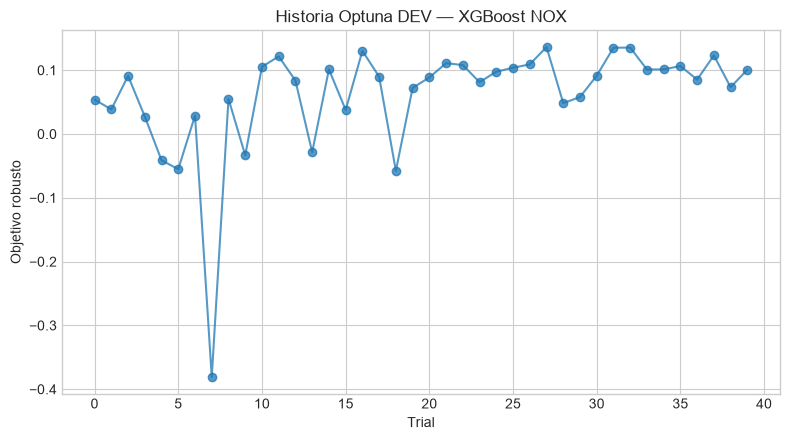

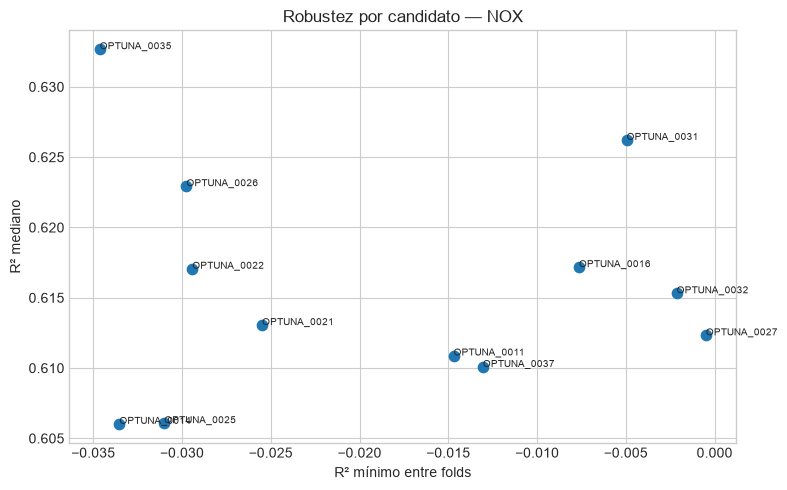

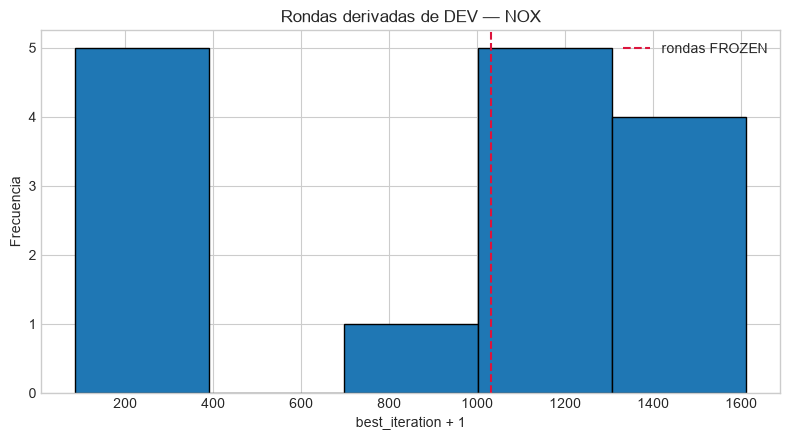

In [18]:
# [C-08.02] Figuras DEV-only
plt.style.use("seaborn-v0_8-whitegrid")

complete_view = TRIALS_TABLE.loc[TRIALS_TABLE.state.eq("COMPLETE")].copy()
if not complete_view.empty and "value" in complete_view:
    figure, axis = plt.subplots(figsize=(8, 4.5))
    axis.plot(complete_view.trial_number, complete_view.value, "o-", alpha=0.75)
    axis.set(
        title=f"Historia Optuna DEV — XGBoost {TARGET}",
        xlabel="Trial",
        ylabel="Objetivo robusto",
    )
    figure.tight_layout()
    figure.savefig(
        PATHS.figures / "01_historia_optuna_dev.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

if not DEVELOPMENT_RANKING.empty:
    view = DEVELOPMENT_RANKING.head(12).sort_values("R2_min")
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.scatter(view.R2_min, view.R2_median, s=55)
    for _, row in view.iterrows():
        axis.annotate(str(row.candidate_id), (row.R2_min, row.R2_median), fontsize=7)
    axis.set(
        title=f"Robustez por candidato — {TARGET}",
        xlabel="R² mínimo entre folds",
        ylabel="R² mediano",
    )
    figure.tight_layout()
    figure.savefig(
        PATHS.figures / "02_robustez_candidatos_dev.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

if RUN_MODE == "FULL_AUTO":
    figure, axis = plt.subplots(figsize=(8, 4.5))
    axis.hist(champion_folds.effective_trees, bins="auto", edgecolor="black")
    axis.axvline(
        FINAL_TRAINING_POLICY["final_n_estimators"],
        color="crimson",
        linestyle="--",
        label="rondas FROZEN",
    )
    axis.set(
        title=f"Rondas derivadas de DEV — {TARGET}",
        xlabel="best_iteration + 1",
        ylabel="Frecuencia",
    )
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        PATHS.figures / "03_rondas_finales_dev.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()


### C-08.03 / ART-06 — Informe, hashes y cierre

**Salida:** inventario verificable de artefactos y declaración explícita de
que TEST permaneció cerrado.


In [19]:
# [C-08.03] Persistencia terminal y resumen
report = f'''# Optimización XGBoost {TARGET} walk-forward R1

- Modo ejecutado: {RUN_MODE}.
- Dispositivo: {DEVICE}.
- Trials intentados: {attempted_trials(study)}.
- Trials completos: {complete_trials(study)}.
- Política de anclas: {ANCHOR_EXECUTION_POLICY}.
- Folds por candidato completo: WF01, WF02 y WF03.
- TEST 2015 materializado: 0 filas.
- SHA-256 de 2015 calculado: no.
- Modelo: gbtree/hist, RAW_9, exclusivamente data-driven.
- Restricciones monotónicas: ninguna.
- Estado FROZEN: {RUN_MODE == 'FULL_AUTO' and FROZEN_MANIFEST is not None}.

Los resultados caracterizan validación prospectiva anual dentro de DEV
2011–2014. La frontera WF04 (2015) permanece reservada para FINAL. No se
afirma extrapolación fuera del periodo ni conformidad regulatoria.
'''
atomic_text(
    PATHS.reports / "INFORME_TECNICO_XGBOOST_NOX_WF_OPT_R1.md",
    report,
)

if RUN_MODE == "FULL_AUTO":
    expected_figures = [
        PATHS.figures / "01_historia_optuna_dev.png",
        PATHS.figures / "02_robustez_candidatos_dev.png",
        PATHS.figures / "03_rondas_finales_dev.png",
    ]
    missing_figures = [
        str(path) for path in expected_figures if not path.is_file()
    ]
    if missing_figures:
        raise FileNotFoundError(f"Figuras OPT FROZEN ausentes: {missing_figures}")

artifact_paths = [
    path
    for path in sorted(PATHS.work.rglob("*"))
    if path.is_file() and not path.name.startswith("HASHES_")
]
ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in artifact_paths
    ]
)
atomic_csv(
    PATHS.audit / "HASHES_XGBOOST_NOX_WF_OPT_R1.csv",
    ARTIFACT_HASHES,
)
print(
    {
        "estado": "FROZEN" if FROZEN_MANIFEST else "SMOKE_COMPLETE",
        "test_target_rows_materialized": 0,
        "test_sha256_computed": False,
        "artefactos": len(ARTIFACT_HASHES),
        "salida": str(PATHS.work),
    }
)


{'estado': 'FROZEN', 'test_target_rows_materialized': 0, 'test_sha256_computed': False, 'artefactos': 26, 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_xgboost_nox_wf_opt_r1_poc_efficient'}


## OUT-01 — Registro de versión

**R1_POC_EFFICIENT:** primera implementación XGBoost walk-forward para NOX.
Consume `WF_PROTOCOL_R1`, evalúa las tres fronteras DEV completas, conserva
2015 cerrado y elimina por diseño toda física PINN. La cuarta ancla transfiere
el campeón NOX interpolativo `OPTUNA_0047`; la campaña FULL debe completarse
antes de ejecutar FINAL.
